<a href="https://colab.research.google.com/github/vedant331/Titanic-Survival-Prediction/blob/main/Titanic_Survive_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
train_pd = pd.read_csv('/kaggle/input/titanic/train.csv')
test_pd = pd.read_csv('/kaggle/input/titanic/test.csv')

train_pd = pd.read_csv('/content/drive/MyDrive/train.csv')
test_pd = pd.read_csv('/content/drive/MyDrive/test.csv')

display(train_pd)
display(test_pd)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


# Data Description

In [88]:
train_pd.head()
train_pd.describe()
train_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [89]:
train_pd.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [4]:
survived = train_pd['Survived']
train_pd = train_pd.drop(['Survived'],axis=1)

display(train_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [53]:
train_idx = train_pd['PassengerId']
test_idx = test_pd['PassengerId']

combined_pd = pd.concat([train_pd,test_pd]).reset_index(drop=True)
display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [54]:
print('Null values:')
print(combined_pd.isnull().sum())

Null values:
PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


# Filling Age values having null

,Age
Pclass,
1,39.0
2,29.0
3,24.0


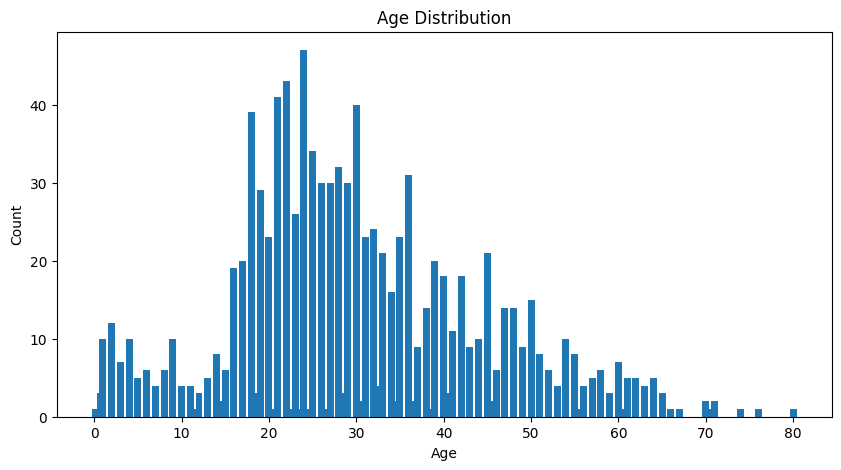

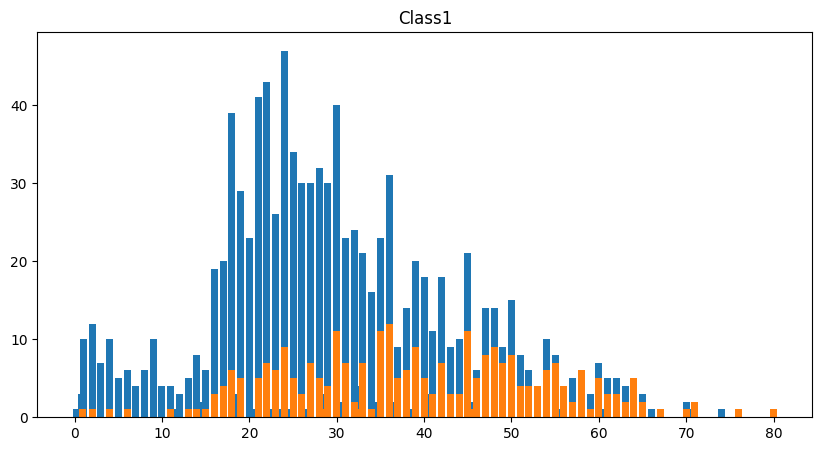

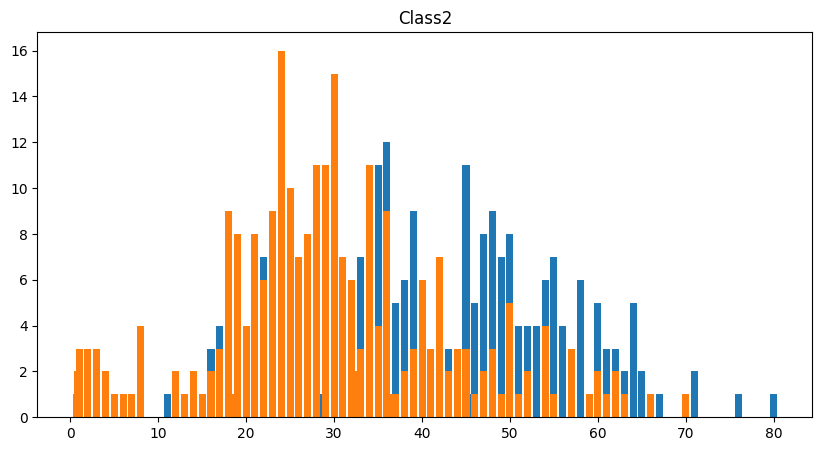

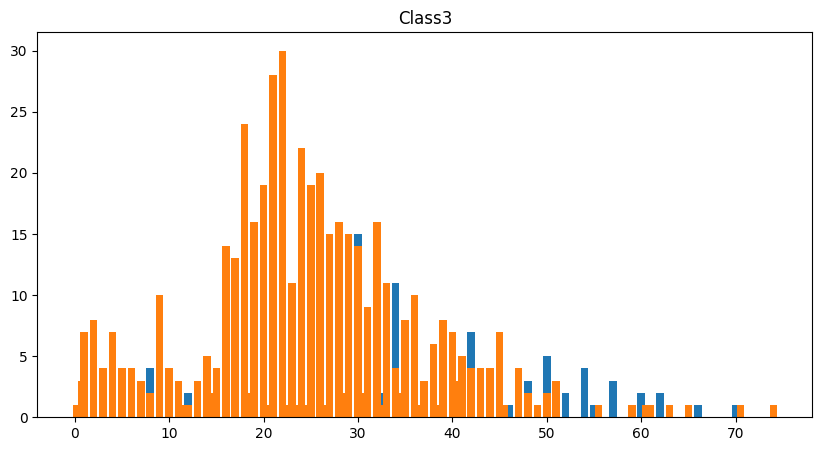

In [55]:
y = combined_pd['Age'].value_counts()
x = y.index.values

plt.figure(figsize=(10,5))
plt.bar(x,y)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

class_age = combined_pd[['Pclass','Age']]

for i in range(1,4):
  plt.figure(figsize=(10,5))
  plt.bar(x,y)
  plt.title('Class'+str(i))
  y = class_age[class_age['Pclass'] == i]['Age'].value_counts()
  x = y.index.values
  plt.bar(x,y)


medians = class_age.groupby('Pclass').median()
medians


In [56]:
for i in range(3):
  idx = np.where((combined_pd['Pclass']==i+1)&combined_pd['Age'].isnull())[0]
  combined_pd.loc[idx,'Age'] = medians.values[i][0]

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,NaN,S


# Filling row having column Fare null

In [91]:
# display(combined_pd[combined_pd['Fare'].isnull()])


sim_fares = combined_pd[(combined_pd['Pclass']==3)& (combined_pd['Embarked']=='S')]['Fare']
print("Median",sim_fares.median())

plt.hist(sim_fares)
plt.plot()

combined_pd['Fare'].fillna(sim_fares.median(),inplace=True)


KeyError: 'Fare'

# Filling Embarked Values having null

---



In [92]:
display(combined_pd[combined_pd['Embarked'].isnull()])

sim_emb = combined_pd[(combined_pd['Pclass']==1)& (combined_pd['Fare'] >= 70)&(combined_pd['Fare'] <= 90)]['Embarked']
print(sim_emb.value_counts())

combined_pd['Embarked'].fillna('C',inplace=True)



,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Title,Age_Bin,Fare_bin,Num_family
PassengerId,,,,,,,,,,


KeyError: 'Fare'

# Filling Cabin T -> M(max cabin)

In [59]:
combined_pd['Cabin'].fillna('M',inplace=True) # filled 'M' where Cabin is null
combined_pd['Cabin'] = combined_pd['Cabin'].str[0] # taken first Char from Cabin

print(combined_pd['Cabin'].value_counts())

idx = np.where(combined_pd['Cabin'] == 'T')[0] # loc where Cabin is 'T' stored in var idx
combined_pd.loc[idx,'Cabin'] = 'M' # replaced it with 'M'

print(combined_pd['Cabin'].value_counts())

Cabin
M    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64
Cabin
M    1015
C      94
B      65
D      46
E      41
A      22
F      21
G       5
Name: count, dtype: int64


/tmp/ipykernel_7351/172436233.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_pd['Cabin'].fillna('M',inplace=True) # filled 'M' where Cabin is null


In [60]:
print(combined_pd.isnull().sum())

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [61]:
display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S


In [62]:
print(combined_pd.nunique())  # how many unique values are there in a particular column
print(combined_pd['Pclass'].unique())

PassengerId    1309
Pclass            3
Name           1307
Sex               2
Age              98
SibSp             7
Parch             8
Ticket          929
Fare            281
Cabin             8
Embarked          3
dtype: int64
[3 1 2]


In [63]:
print(combined_pd['Name'].unique())

names = combined_pd['Name']

last_names = []
titles = []
first_names = []

for name in names:
  if ',' not in name:
    last_names.append('')
  else:
    last,name = name.split(', ',1)
    last_names.append(last)

  if '.' not in name:
    titles.append('')
  else:
    title,first = name.split('.',1)
    titles.append(title)
    first_names.append(first)

last_names = np.array(last_names)
titles = np.array(titles)
first_names = np.array(first_names)

idx = np.where(np.isin(titles,['Capt','Col','Major']))
titles[idx] = 'Military'

idx = np.where(np.isin(titles,['Don','Dona','Jonkheer','Lady','Sir','Master','the Countees']))
titles[idx] = 'Nobility'

idx = np.where(np.isin(titles,['Miss','Mlle','Ms']))
titles[idx] = 'Ms'

idx = np.where(np.isin(titles,['Mme','Mrs']))
titles[idx] = 'Mrs'



print('\n')
print(np.unique(titles,return_counts=True))

combined_pd['Title'] = titles
display(combined_pd)


['Braund, Mr. Owen Harris'
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Heikkinen, Miss. Laina' ... 'Saether, Mr. Simon Sivertsen'
 'Ware, Mr. Frederick' 'Peter, Master. Michael J']


(array(['Dr', 'Military', 'Mr', 'Mrs', 'Ms', 'Nobility', 'Rev',
       'the Countess'], dtype='<U12'), array([  8,   7, 757, 198, 264,  66,   8,   1]))


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr


In [64]:
print(combined_pd['Age'].min(),combined_pd['Age'].max())

bins = np.array([0,10,20,30,40,50,60,80])

combined_pd['Age_Bin'] = pd.cut(combined_pd['Age'],bins)
display(combined_pd)

0.17 80.0


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]"
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]"
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]"
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]"
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,"(20, 30]"
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,"(30, 40]"
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,"(30, 40]"
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,"(20, 30]"


In [65]:
ticket_dict = dict(combined_pd['Ticket'].value_counts())

combined_pd['tkt_count'] = combined_pd['Ticket'].map(ticket_dict)

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin,tkt_count
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]",1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]",2
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]",1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]",2
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,"(20, 30]",1
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,"(30, 40]",3
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,"(30, 40]",1
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,"(20, 30]",1


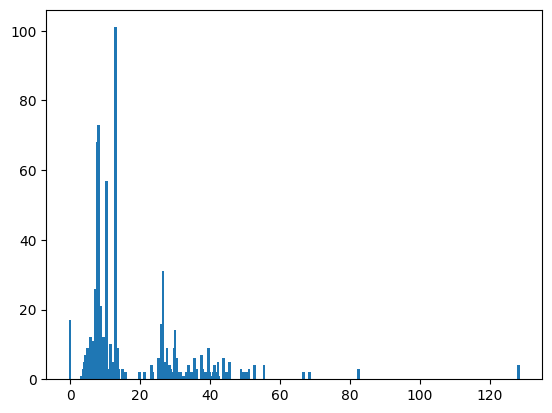

0.0
128.0823


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin,tkt_count,Fare_per_ticket,Fare_bin
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]",1,7.250000,"(0, 20]"
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]",2,35.641650,"(20, 40]"
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]",1,7.925000,"(0, 20]"
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]",2,26.550000,"(20, 40]"
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]",1,8.050000,"(0, 20]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,"(20, 30]",1,8.050000,"(0, 20]"
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,"(30, 40]",3,36.300000,"(20, 40]"
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,"(30, 40]",1,7.250000,"(0, 20]"
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,"(20, 30]",1,8.050000,"(0, 20]"


In [66]:
combined_pd['Fare_per_ticket'] = combined_pd['Fare']/combined_pd['tkt_count']

plt.bar(combined_pd['Fare_per_ticket'].value_counts().index.values,combined_pd['Fare_per_ticket'].value_counts())
plt.show()

print(combined_pd['Fare_per_ticket'].min())
print(combined_pd['Fare_per_ticket'].max())

bins = [0,20,40,60,80,150]
combined_pd['Fare_bin'] = pd.cut(combined_pd['Fare_per_ticket'],bins)

display(combined_pd)

In [67]:
combined_pd['Num_family'] = combined_pd['SibSp']+combined_pd['Parch'] + 1

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_Bin,tkt_count,Fare_per_ticket,Fare_bin,Num_family
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]",1,7.250000,"(0, 20]",2
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]",2,35.641650,"(20, 40]",2
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]",1,7.925000,"(0, 20]",1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]",2,26.550000,"(20, 40]",2
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]",1,8.050000,"(0, 20]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,"(20, 30]",1,8.050000,"(0, 20]",1
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,"(30, 40]",3,36.300000,"(20, 40]",1
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,"(30, 40]",1,7.250000,"(0, 20]",1
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,"(20, 30]",1,8.050000,"(0, 20]",1


In [68]:
combined_pd.drop(['Name','Age','Ticket','Fare','tkt_count','Fare_per_ticket'],axis=1,inplace=True)

display(combined_pd)

,PassengerId,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Title,Age_Bin,Fare_bin,Num_family
0,1,3,male,1,0,M,S,Mr,"(20, 30]","(0, 20]",2
1,2,1,female,1,0,C,C,Mrs,"(30, 40]","(20, 40]",2
2,3,3,female,0,0,M,S,Ms,"(20, 30]","(0, 20]",1
3,4,1,female,1,0,C,S,Mrs,"(30, 40]","(20, 40]",2
4,5,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,male,0,0,M,S,Mr,"(20, 30]","(0, 20]",1
1305,1306,1,female,0,0,C,C,Nobility,"(30, 40]","(20, 40]",1
1306,1307,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1
1307,1308,3,male,0,0,M,S,Mr,"(20, 30]","(0, 20]",1


In [69]:
print(combined_pd.nunique())

PassengerId    1309
Pclass            3
Sex               2
SibSp             7
Parch             8
Cabin             8
Embarked          3
Title             8
Age_Bin           7
Fare_bin          5
Num_family        9
dtype: int64


In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

In [71]:
combined_pd.set_index('PassengerId',inplace=True)

display(combined_pd)

,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Title,Age_Bin,Fare_bin,Num_family
PassengerId,,,,,,,,,,
1,3,male,1,0,M,S,Mr,"(20, 30]","(0, 20]",2
2,1,female,1,0,C,C,Mrs,"(30, 40]","(20, 40]",2
3,3,female,0,0,M,S,Ms,"(20, 30]","(0, 20]",1
4,1,female,1,0,C,S,Mrs,"(30, 40]","(20, 40]",2
5,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1
...,...,...,...,...,...,...,...,...,...,...
1305,3,male,0,0,M,S,Mr,"(20, 30]","(0, 20]",1
1306,1,female,0,0,C,C,Nobility,"(30, 40]","(20, 40]",1
1307,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1


In [72]:
from sklearn.preprocessing import LabelEncoder

label_enc = combined_pd.copy()
label_enc = label_enc.astype(str)

label_enc = label_enc.apply(LabelEncoder().fit_transform)

display(label_enc)

,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Title,Age_Bin,Fare_bin,Num_family
PassengerId,,,,,,,,,,
1,2,1,1,0,7,2,2,2,0,2
2,0,0,1,0,2,0,3,3,1,2
3,2,0,0,0,7,2,4,2,0,0
4,0,0,1,0,2,2,3,3,1,2
5,2,1,0,0,7,2,2,3,0,0
...,...,...,...,...,...,...,...,...,...,...
1305,2,1,0,0,7,2,2,2,0,0
1306,0,0,0,0,2,0,5,3,1,0
1307,2,1,0,0,7,2,2,3,0,0


In [73]:
one_hot = label_enc.copy()

one_hot = pd.get_dummies(one_hot,columns=['Sex','Embarked','Title'])

display(one_hot)

,Pclass,SibSp,Parch,Cabin,Age_Bin,Fare_bin,Num_family,Sex_0,Sex_1,Embarked_0,Embarked_1,Embarked_2,Title_0,Title_1,Title_2,Title_3,Title_4,Title_5,Title_6,Title_7
PassengerId,,,,,,,,,,,,,,,,,,,,
1,2,1,0,7,2,0,2,False,True,False,False,True,False,False,True,False,False,False,False,False
2,0,1,0,2,3,1,2,True,False,True,False,False,False,False,False,True,False,False,False,False
3,2,0,0,7,2,0,0,True,False,False,False,True,False,False,False,False,True,False,False,False
4,0,1,0,2,3,1,2,True,False,False,False,True,False,False,False,True,False,False,False,False
5,2,0,0,7,3,0,0,False,True,False,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,2,0,0,7,2,0,0,False,True,False,False,True,False,False,True,False,False,False,False,False
1306,0,0,0,2,3,1,0,True,False,True,False,False,False,False,False,False,False,True,False,False
1307,2,0,0,7,3,0,0,False,True,False,False,True,False,False,True,False,False,False,False,False


In [75]:
X = one_hot.loc[train_idx].values
y = survived.values

scaler = MinMaxScaler()
scaler.fit(X)
X_scaled = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=0)

print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(712, 20) (179, 20) (712,) (179,)


In [81]:
# AdaBoostClassifier

from sklearn.ensemble import AdaBoostClassifier
adf = AdaBoostClassifier(random_state=0)
adf.fit(X_train,y_train).score(X_test,y_test)

0.7988826815642458

In [82]:
# Hyperparameter Tuning

params = {'n_estimators':[50,100,200,300,400,500,800,1000],
          'learning_rate':[1.0,0.1,0.01,0.001],
          }
rd_search = RandomizedSearchCV(
                  AdaBoostClassifier(random_state=0),
                  params,scoring='accuracy',
                  random_state=0,
                  cv=5
              )
rd_search.fit(X_train,y_train)

rd_params = rd_search.best_params_
print(rd_params,'\n')
print('Train Accuracy:',rd_search.best_score_)
pds = rd_search.predict(X_test)
print('Test Accuracy:',accuracy_score(pds,y_test))

{'n_estimators': 200, 'learning_rate': 1.0} 

Train Accuracy: 0.8258642765685019
Test Accuracy: 0.8100558659217877


In [83]:
# Hyperparameter Tuning

n_estimators = np.linspace(rd_params['n_estimators']-50,rd_params['n_estimators']+50,3).astype(int)

learning_rate = np.linspace(rd_params['learning_rate']*.9,rd_params['learning_rate']*1.1,3)

params = {'n_estimators':n_estimators,
          'learning_rate':learning_rate
          }
grd_search = GridSearchCV(
                  AdaBoostClassifier(random_state=0),
                  params,scoring='accuracy',
                  cv=5
              )
grd_search.fit(X_train,y_train)

grd_params = grd_search.best_params_
print(grd_params,'\n')
print('Train Accuracy:',grd_search.best_score_)
pds = grd_search.predict(X_test)
print('Test Accuracy:',accuracy_score(pds,y_test))

{'learning_rate': np.float64(1.0), 'n_estimators': np.int64(250)} 

Train Accuracy: 0.8272628779671033
Test Accuracy: 0.8100558659217877


In [76]:
clf = RandomForestClassifier(random_state=0)
clf.fit(X_train,y_train).score(X_test,y_test)

0.8044692737430168

In [79]:
# HyperParameter Tuning

params = {'criterion':['gini','entropy'],
          'n_estimators':[20,50,100,200,300,400,500,800,1000],
          'max_depth':np.arange(3,50),
          'min_samples_split':np.arange(1,1000),
          'max_features':['sqrt','log2'],
          'max_samples':np.linspace(0.1,0.9,10)
          }

rand_search = RandomizedSearchCV(
                  RandomForestClassifier(random_state=0),
                  params,scoring='accuracy',
                  random_state=0,
                  cv=5
              )
rand_search.fit(X_train,y_train)

rand_params = rand_search.best_params_
print(rand_params,'\n')
print('Train Accuracy:',rand_search.best_score_)
preds = rand_search.predict(X_test)
print('Test Accuracy:',accuracy_score(preds,y_test))

{'n_estimators': 200, 'min_samples_split': np.int64(16), 'max_samples': np.float64(0.6333333333333333), 'max_features': 'sqrt', 'max_depth': np.int64(49), 'criterion': 'gini'} 

Train Accuracy: 0.8314488328572835
Test Accuracy: 0.8100558659217877


In [80]:
# HyperParameter Tuning

n_estimators = np.linspace(rand_params['n_estimators']-10,rand_params['n_estimators']+10,3).astype(int)

min_samples_split = np.arange(rand_params['min_samples_split']-3,rand_params['min_samples_split']+3).astype(int)

max_samples = np.linspace(rand_params['max_samples']-.05,rand_params['max_samples']+.05,6)

max_depth = np.arange(rand_params['max_depth']-5,rand_params['max_depth']+5).astype(int
                                                                                    )


params = {'criterion':[rand_params['criterion']],
          'n_estimators':n_estimators,
          'max_depth':max_depth,
          'min_samples_split':min_samples_split,
          'max_features':[rand_params['max_features']],
          'max_samples': max_samples
          }

grid_search = GridSearchCV(
                  RandomForestClassifier(random_state=0),
                  params,scoring='accuracy',
                  cv=5
              )
grid_search.fit(X_train,y_train)

grid_params = grid_search.best_params_
print(grid_params,'\n')
print('Train Accuracy:',grid_search.best_score_)
preds = grid_search.predict(X_test)
print('Test Accuracy:',accuracy_score(preds,y_test))

{'criterion': 'gini', 'max_depth': np.int64(44), 'max_features': 'sqrt', 'max_samples': np.float64(0.6033333333333333), 'min_samples_split': np.int64(17), 'n_estimators': np.int64(190)} 

Train Accuracy: 0.8342657342657341
Test Accuracy: 0.8268156424581006


In [84]:
X_kaggle_test = one_hot.loc[test_idx].values

X_kaggle_test = scaler.transform(X_kaggle_test)

In [85]:
kaggle_preds = grid_search.predict(X_kaggle_test)

In [86]:
submission = pd.DataFrame({
    "PassengerId": test_idx,
    "Survived": kaggle_preds
})

submission.to_csv("submission.csv", index=False)

print(submission.head())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [87]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>